In [3]:
library(pROC)
library(caret)
library(dplyr)
library(glmnet)

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Loading required package: lattice


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix

Loaded glmnet 4.1-8



In [3]:
# cellCounts = read.csv("/vol/projects/CIIM/cohorts_old/500FG/Molecular_phenotype/500FG_cellCounts_cellPerc.csv")
# rownames(cellCounts) <- cellCounts[,1]
# cellCounts <- cellCounts[,-1]
# head(cellCounts)
# dim(cellCounts)
# any(is.na(cellCounts))

,IT1,IT2,IT3,IT4,IT5,IT6,IT7,IT8,IT9,IT11,⋯,IT209,IT210,IT211,IT212,IT213,IT214,IT215,IT216,IT217,IT218
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV003,3037075,338003,266556,37873,21738,1283869,997227,39248,55644,132535,⋯,9.040527,0.07209519,0.004963328,0.0010208037,0.037761479,0.007766374,0.06958706,0.014311916,0.25001507,0.05142040
HV004,12837180,534745,455914,31178,18441,1960252,1214855,439036,44759,169069,⋯,11.974640,0.05817235,0.004506337,0.0008555986,0.023997141,0.004556232,0.07438069,0.014122335,0.23504990,0.04462790
HV006,3155740,253856,212280,19859,10034,1681848,1262400,155528,76864,145687,⋯,6.433164,0.05743766,0.002618931,0.0007687970,0.022363485,0.006564885,0.03528763,0.010358816,0.14387069,0.04223378
HV007,2877976,230940,196798,16245,12205,1223816,793042,222175,25083,72128,⋯,11.047047,0.04907738,0.002692965,0.0006421505,0.023341514,0.005565897,0.02711241,0.006465086,0.15589729,0.03717447
HV008,3378569,307137,243099,19421,15310,1444715,1067657,129387,102714,74729,⋯,12.929089,0.04153785,0.001325280,0.0003152580,0.004663773,0.001109419,0.07441804,0.017702579,0.09727829,0.02314058
HV012,2357939,355273,282569,29434,26797,2370438,1692438,366060,63943,126161,⋯,4.192742,0.03743869,0.002327464,0.0005257336,0.009639233,0.002177335,0.05261497,0.011884807,0.10577163,0.02389197


[1] 515 206

[1] FALSE

In [1]:
cellCounts = read.table("/vol/projects/CIIM/cohorts_old/500FG/Molecular_phenotype/500FG_inverse_rank_normalized_cellcounts.txt", header = TRUE, stringsAsFactors = FALSE)
head(cellCounts)
dim(cellCounts)
any(is.na(cellCounts))

,IT1,IT2,IT3,IT4,IT5,IT7,IT8,IT9,IT11,IT12,⋯,IT84,IT85,IT86,IT87,IT88,IT89,IT90,IT93,IT94,IT95
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV003,-0.7045564,-0.4783576,-0.3823108,-0.0522959,-0.1945046,-1.1736302,-2.8877786,-0.32023844,0.01580384,-0.8775032,⋯,-0.1304413,0.41124576,-0.16485366,-0.12063932,0.3023744,-0.7108026,-1.4626983,-0.6798409,-0.9590444,0.1673187
HV004,2.4682104,0.3433585,0.5761697,-0.3614678,-0.4783576,-0.6615738,1.0267065,-0.57904232,0.41124576,-0.5848020,⋯,0.4920324,0.89551086,-0.06690952,-0.14025590,0.2218351,-0.3823108,-0.5336287,0.1623896,0.1623896,0.2468250
HV005,0.2118786,-1.3576090,-1.2549268,-0.5963799,-0.7553342,-0.3927943,0.1230887,0.98635829,0.75857199,-0.8081388,⋯,1.0267065,0.04986147,-0.46748183,0.21685414,-0.2593771,-0.2543515,-1.1736302,-0.6021990,-0.6859803,0.2019431
HV006,-0.6435248,-0.9982921,-0.8014168,-1.0818022,-1.4626983,-0.5336287,-0.6080384,0.01094088,0.15746453,-0.4458936,⋯,-0.5963799,0.19202751,-1.60437056,-1.25492680,-1.0308337,-1.5375801,-1.7648168,-0.3718691,-0.6525227,-0.6021990
HV007,-0.8632995,-1.1736302,-0.8562626,-1.3824671,-1.0994290,-1.6994536,-0.1206393,-1.27659327,-1.12652869,-1.6791979,⋯,-1.5219124,-0.29474822,-2.15658740,-2.10931320,-1.3824671,-2.4200373,-2.5228989,-1.2338339,-2.3377804,-1.1174042
HV008,-0.4620647,-0.6375551,-0.5733018,-1.1083718,-0.7880801,-0.9982921,-0.9361896,0.40068536,-1.08180216,-0.8148976,⋯,0.1821308,-0.85626255,0.12308870,-0.00850951,0.1771891,0.1084030,-0.1994624,-0.4458936,0.3485208,-1.0391412


[1] 515  73

[1] FALSE

In [4]:
basicPhenos = read.csv("/vol/projects/yzhang/500FG_aging/output/02_Olink/Age_group_basicPhenos.csv")
# prepare cytokine_filter and pheno_filter_match
idx = intersect(rownames(cellCounts), basicPhenos$ID_500fg) 
length(idx) #458samples
cellCounts_filter = cellCounts[which(rownames(cellCounts) %in% idx),]
head(cellCounts_filter)  #458samples,1596 metabolite
dim(cellCounts_filter)

basicPhenos_filter = basicPhenos %>% filter(ID_500fg %in% idx)
head(basicPhenos_filter) #458samples
dim(basicPhenos_filter)

sum(rownames(cellCounts_filter) == basicPhenos_filter$ID_500fg)

basicPhenos_filter_match = basicPhenos_filter[match(rownames(cellCounts_filter), basicPhenos_filter$ID_500fg), ]

sum(basicPhenos_filter_match$ID_500fg == rownames(cellCounts))
head(basicPhenos_filter_match) 
dim(basicPhenos_filter_match) #458samples
# write.csv(cellCounts_filter, file = "/vol/projects/yzhang/500FG_aging/input/cellCounts/common_cellCounts_filter_age.csv")
# write.csv(basicPhenos_filter_match, file = "/vol/projects/yzhang/500FG_aging/input/cellCounts/common_basicPhenos_filter_match_cellCounts_age.csv")

[1] 508

,IT1,IT2,IT3,IT4,IT5,IT7,IT8,IT9,IT11,IT12,⋯,IT84,IT85,IT86,IT87,IT88,IT89,IT90,IT93,IT94,IT95
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV003,-0.7045564,-0.4783576,-0.3823108,-0.0522959,-0.1945046,-1.1736302,-2.8877786,-0.32023844,0.01580384,-0.8775032,⋯,-0.1304413,0.41124576,-0.16485366,-0.12063932,0.3023744,-0.7108026,-1.4626983,-0.6798409,-0.9590444,0.1673187
HV004,2.4682104,0.3433585,0.5761697,-0.3614678,-0.4783576,-0.6615738,1.0267065,-0.57904232,0.41124576,-0.5848020,⋯,0.4920324,0.89551086,-0.06690952,-0.14025590,0.2218351,-0.3823108,-0.5336287,0.1623896,0.1623896,0.2468250
HV005,0.2118786,-1.3576090,-1.2549268,-0.5963799,-0.7553342,-0.3927943,0.1230887,0.98635829,0.75857199,-0.8081388,⋯,1.0267065,0.04986147,-0.46748183,0.21685414,-0.2593771,-0.2543515,-1.1736302,-0.6021990,-0.6859803,0.2019431
HV006,-0.6435248,-0.9982921,-0.8014168,-1.0818022,-1.4626983,-0.5336287,-0.6080384,0.01094088,0.15746453,-0.4458936,⋯,-0.5963799,0.19202751,-1.60437056,-1.25492680,-1.0308337,-1.5375801,-1.7648168,-0.3718691,-0.6525227,-0.6021990
HV007,-0.8632995,-1.1736302,-0.8562626,-1.3824671,-1.0994290,-1.6994536,-0.1206393,-1.27659327,-1.12652869,-1.6791979,⋯,-1.5219124,-0.29474822,-2.15658740,-2.10931320,-1.3824671,-2.4200373,-2.5228989,-1.2338339,-2.3377804,-1.1174042
HV008,-0.4620647,-0.6375551,-0.5733018,-1.1083718,-0.7880801,-0.9982921,-0.9361896,0.40068536,-1.08180216,-0.8148976,⋯,0.1821308,-0.85626255,0.12308870,-0.00850951,0.1771891,0.1084030,-0.1994624,-0.4458936,0.3485208,-1.0391412


[1] 508  73

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
1,2,HV043,male,18,182,50,15.09480,Married,University student,European,Rarely,Yes,Yes,16,12,346,2013,Group 1
2,16,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
3,41,HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
4,51,HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
5,56,HV497,female,18,157,49,19.87910,Married,Hogeschool opleiding (HBO),Asian,Rarely,No,No,24,11,324,2014,Group 1
6,148,HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1


[1] 508  18

[1] 0

Warning message in basicPhenos_filter_match$ID_500fg == rownames(cellCounts):
“longer object length is not a multiple of shorter object length”


[1] 206

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
293,257,HV003,female,24,173,68,22.72044,Married,University degree,European,Rarely,Yes,Yes,26,8,236,2013,Group 4
92,258,HV004,female,20,173,65,21.71807,Married,University degree,European,Rarely,Yes,No,26,8,236,2013,Group 2
197,254,HV005,female,22,178,64,20.19947,Married,University student,European,Once a month,Yes,Yes,5,9,245,2013,Group 3
319,530,HV006,female,24,168,58,20.54989,Married,University degree,European,Rarely,Yes,No,NA,NA,NA,NA,Group 4
246,259,HV007,male,23,192,87,23.60026,Married,University degree,European,Rarely,No,Yes,26,8,236,2013,Group 3
337,260,HV008,male,25,180,74,22.83951,Single living alone,Primary education,European,Once a month,Yes,Yes,26,8,236,2013,Group 4


[1] 508  18

In [5]:
cellCounts_age <- cbind(cellCounts_filter, Age = basicPhenos_filter_match$Age)
head(cellCounts_age)
dim(cellCounts_age)

,IT1,IT2,IT3,IT4,IT5,IT7,IT8,IT9,IT11,IT12,⋯,IT85,IT86,IT87,IT88,IT89,IT90,IT93,IT94,IT95,Age
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
HV003,-0.7045564,-0.4783576,-0.3823108,-0.0522959,-0.1945046,-1.1736302,-2.8877786,-0.32023844,0.01580384,-0.8775032,⋯,0.41124576,-0.16485366,-0.12063932,0.3023744,-0.7108026,-1.4626983,-0.6798409,-0.9590444,0.1673187,24
HV004,2.4682104,0.3433585,0.5761697,-0.3614678,-0.4783576,-0.6615738,1.0267065,-0.57904232,0.41124576,-0.5848020,⋯,0.89551086,-0.06690952,-0.14025590,0.2218351,-0.3823108,-0.5336287,0.1623896,0.1623896,0.2468250,20
HV005,0.2118786,-1.3576090,-1.2549268,-0.5963799,-0.7553342,-0.3927943,0.1230887,0.98635829,0.75857199,-0.8081388,⋯,0.04986147,-0.46748183,0.21685414,-0.2593771,-0.2543515,-1.1736302,-0.6021990,-0.6859803,0.2019431,22
HV006,-0.6435248,-0.9982921,-0.8014168,-1.0818022,-1.4626983,-0.5336287,-0.6080384,0.01094088,0.15746453,-0.4458936,⋯,0.19202751,-1.60437056,-1.25492680,-1.0308337,-1.5375801,-1.7648168,-0.3718691,-0.6525227,-0.6021990,24
HV007,-0.8632995,-1.1736302,-0.8562626,-1.3824671,-1.0994290,-1.6994536,-0.1206393,-1.27659327,-1.12652869,-1.6791979,⋯,-0.29474822,-2.15658740,-2.10931320,-1.3824671,-2.4200373,-2.5228989,-1.2338339,-2.3377804,-1.1174042,23
HV008,-0.4620647,-0.6375551,-0.5733018,-1.1083718,-0.7880801,-0.9982921,-0.9361896,0.40068536,-1.08180216,-0.8148976,⋯,-0.85626255,0.12308870,-0.00850951,0.1771891,0.1084030,-0.1994624,-0.4458936,0.3485208,-1.0391412,25


[1] 508  74

In [6]:
##replaced the Inf value
# Count the number of infinite values in each column
inf_counts <- sapply(cellCounts_age, function(col) sum(is.infinite(col)))
inf_counts[inf_counts > 0] 

# Replace infinite values with the maximum finite value in each numeric column
cellCounts_age <- lapply(cellCounts_age, function(col) {
  if (is.numeric(col)) {  # Ensure the column is numeric
    col[is.infinite(col)] <- max(col[!is.infinite(col)], na.rm = TRUE)  # Replace Inf
  }
  return(col)
})

# Convert back to a data frame 
cellCounts_age <- as.data.frame(cellCounts_age)
rownames(cellCounts_age) <- rownames(cellCounts_filter)

head(cellCounts_age)

named integer(0)

,IT1,IT2,IT3,IT4,IT5,IT7,IT8,IT9,IT11,IT12,⋯,IT85,IT86,IT87,IT88,IT89,IT90,IT93,IT94,IT95,Age
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
HV003,-0.7045564,-0.4783576,-0.3823108,-0.0522959,-0.1945046,-1.1736302,-2.8877786,-0.32023844,0.01580384,-0.8775032,⋯,0.41124576,-0.16485366,-0.12063932,0.3023744,-0.7108026,-1.4626983,-0.6798409,-0.9590444,0.1673187,24
HV004,2.4682104,0.3433585,0.5761697,-0.3614678,-0.4783576,-0.6615738,1.0267065,-0.57904232,0.41124576,-0.5848020,⋯,0.89551086,-0.06690952,-0.14025590,0.2218351,-0.3823108,-0.5336287,0.1623896,0.1623896,0.2468250,20
HV005,0.2118786,-1.3576090,-1.2549268,-0.5963799,-0.7553342,-0.3927943,0.1230887,0.98635829,0.75857199,-0.8081388,⋯,0.04986147,-0.46748183,0.21685414,-0.2593771,-0.2543515,-1.1736302,-0.6021990,-0.6859803,0.2019431,22
HV006,-0.6435248,-0.9982921,-0.8014168,-1.0818022,-1.4626983,-0.5336287,-0.6080384,0.01094088,0.15746453,-0.4458936,⋯,0.19202751,-1.60437056,-1.25492680,-1.0308337,-1.5375801,-1.7648168,-0.3718691,-0.6525227,-0.6021990,24
HV007,-0.8632995,-1.1736302,-0.8562626,-1.3824671,-1.0994290,-1.6994536,-0.1206393,-1.27659327,-1.12652869,-1.6791979,⋯,-0.29474822,-2.15658740,-2.10931320,-1.3824671,-2.4200373,-2.5228989,-1.2338339,-2.3377804,-1.1174042,23
HV008,-0.4620647,-0.6375551,-0.5733018,-1.1083718,-0.7880801,-0.9982921,-0.9361896,0.40068536,-1.08180216,-0.8148976,⋯,-0.85626255,0.12308870,-0.00850951,0.1771891,0.1084030,-0.1994624,-0.4458936,0.3485208,-1.0391412,25


In [7]:
##perform 100 times
# Custom function to train and evaluate the model
train_and_evaluate <- function(data, seed, iteration) {
  set.seed(seed)
  
  # Split data into training and validation sets
  splitSample <- createDataPartition(data$Age, p = 0.7, list = FALSE)
  training <- data[splitSample, ]
  validation <- data[-splitSample, ]
   
    # Set up the grid for hyperparameter tuning
  netGrid <- expand.grid(.alpha = seq(0.1, 0.9, by = 0.1), .lambda = seq(0, 1, by = 0.01))    
  netctrl <- trainControl(method = "repeatedcv", number = 10, repeats = 5) 
  
    # Train the model
  netFit <- train(Age ~ ., data = training, method = "glmnet", metric = "RMSE",
                  tuneGrid = netGrid, trControl = netctrl, preProcess = "scale")
  
  # Make predictions on training and validation sets
  train_predictions <- predict(netFit, newdata = training)
  val_predictions <- predict(netFit, newdata = validation)
  
    # Save predicted age for each sample   
   pred_df <- rbind(
    data.frame(
      iteration = iteration,
      set = "train",
      sample_id = rownames(training),
      Age_true = training$Age,
      Age_pred = as.numeric(train_predictions),
      stringsAsFactors = FALSE
    ),
    data.frame(
      iteration = iteration,
      set = "validation",
      sample_id = rownames(validation),
      Age_true = validation$Age,
      Age_pred = as.numeric(val_predictions),
      stringsAsFactors = FALSE
    )
  )
  # Compute performance metrics for training set
  train_rmse <- sqrt(mean((training$Age - train_predictions)^2))  # RMSE
  train_mse <- mean((training$Age - train_predictions)^2)         # MSE
  train_r_squared <- cor(training$Age, train_predictions)^2       # R²
  
  # Compute performance metrics for validation set
  val_rmse <- sqrt(mean((validation$Age - val_predictions)^2))    # RMSE
  val_mse <- mean((validation$Age - val_predictions)^2)           # MSE
  val_r_squared <- cor(validation$Age, val_predictions)^2         # R²
  
  # Return metrics
  list(
    train_RMSE = train_rmse,
    train_MSE = train_mse,
    train_R2 = train_r_squared,
    val_RMSE = val_rmse,
    val_MSE = val_mse,
    val_R2 = val_r_squared,
    best_model = netFit,
    # selected_features = selected_features,
    predictions = pred_df
  )
}


In [8]:
# Run the training process 100 times
set.seed(1)
results <- lapply(1:100, function(i) train_and_evaluate(cellCounts_age, seed = i, iteration = i))

# Extract metrics for training and validation sets
train_rmse_values <- sapply(results, function(x) x$train_RMSE)
train_mse_values <- sapply(results, function(x) x$train_MSE)
train_r2_values <- sapply(results, function(x) x$train_R2)

val_rmse_values <- sapply(results, function(x) x$val_RMSE)
val_mse_values <- sapply(results, function(x) x$val_MSE)
val_r2_values <- sapply(results, function(x) x$val_R2)

# Calculate mean and standard deviation for each metric
metrics_summary <- data.frame(
  Metric = c("Train RMSE", "Validation RMSE", 
             "Train MSE", "Validation MSE", 
             "Train R²", "Validation R²"),
  Mean = c(mean(train_rmse_values), mean(val_rmse_values),
           mean(train_mse_values), mean(val_mse_values),
           mean(train_r2_values), mean(val_r2_values)),
  SD = c(sd(train_rmse_values), sd(val_rmse_values),
         sd(train_mse_values), sd(val_mse_values),
         sd(train_r2_values), sd(val_r2_values))
)

# Print summary
head(metrics_summary)

,Metric,Mean,SD
,<chr>,<dbl>,<dbl>
1,Train RMSE,7.1634755,0.31824025
2,Validation RMSE,8.2087829,0.42089244
3,Train MSE,51.4156460,4.54425413
4,Validation MSE,67.5594953,6.87174685
5,Train R²,0.7253632,0.02578413
6,Validation R²,0.6469391,0.04009781


In [9]:
saveRDS(results, "/vol/projects/yzhang/500FG_aging/output/12_prediction/elasticnet_orign_sample_feature/cellcount_prediction_elastic_results.rds")

all_predictions <- do.call(rbind, lapply(results, function(x) x$predictions))
write.csv(all_predictions, file = "/vol/projects/yzhang/500FG_aging/output/12_prediction/elasticnet_orign_sample_feature/cellcount_pre_age_elasticnet_orign_sample_feature.csv", row.names = FALSE)

null device 
          1

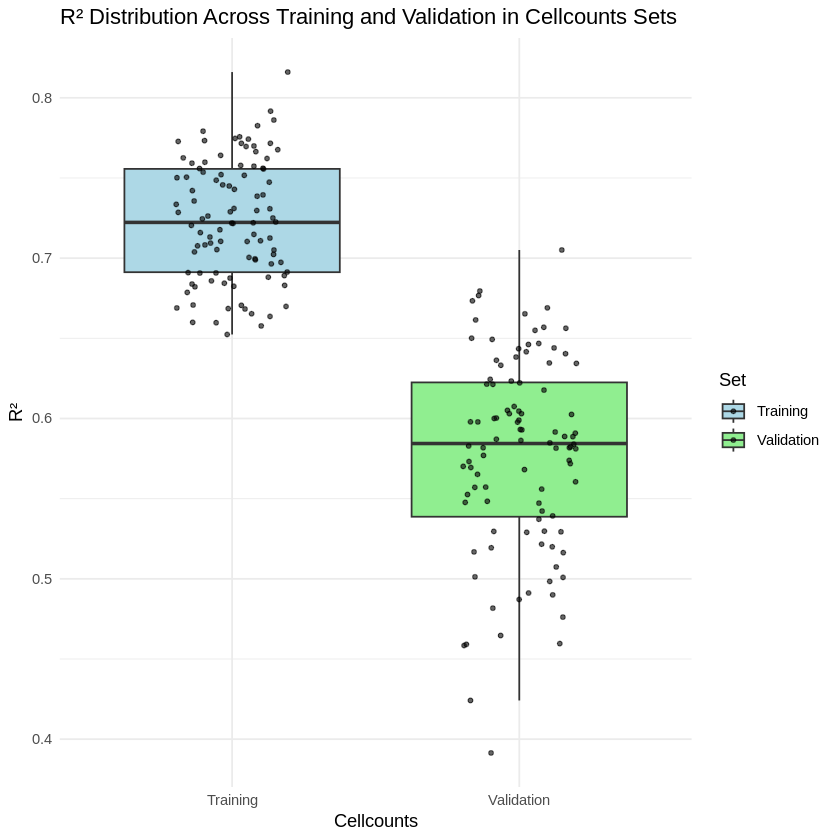

In [16]:
# Combine R² metrics into a single data frame for plotting
plot_data_r2 <- data.frame(
  Set = rep(c("Training", "Validation"), each = 100),
  R2 = c(train_r2_values, val_r2_values)
)

# Plot only R²
ppi <- 300
# png("/vol/projects/yzhang/500FG_aging/output/07_cellcounts/cellcounts_cross_validation.png", 
#     width = 5 * ppi, height = 4 * ppi, res = ppi)

g<-ggplot(plot_data_r2, aes(x = Set, y = R2, fill = Set)) +
  geom_boxplot(outlier.shape = NA) +  # Boxplot without outliers
  geom_jitter(position = position_jitterdodge(), size = 1, alpha = 0.6, color = "black") +  # Scatter points
  labs(title = "R² Distribution Across Training and Validation in Cellcounts Sets",
       x = "Cellcounts",
       y = "R²") +
  theme_minimal() +
  scale_fill_manual(values = c("lightblue", "lightgreen")) +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5))

print(g)
dev.off()
print(g)

In [17]:
save.image("/vol/projects/yzhang/500FG_aging/output/07_cellcounts/cellcounts_elasticnet_orign_sample.Rdata")